# PRCP-1006-Home Loan Default Risk Management




### Problem Statement
The goal of this project is to predict whether a customer will default on a home loan using machine learning techniques.

The dataset consists of multiple relational tables such as:

application_train (main dataset with target)
bureau, bureau_balance
previous_application
credit_card_balance, POS_CASH_balance
installments_payments

Each row represents a loan application, and the target variable is:

1 = Defaulter and
0 = Non-defaulter

### Objectives
1. Perform Exploratory Data Analysis (EDA) to understand data patterns.
2. Identify key factors affecting loan default.
3. Build machine learning models to predict loan default.
4. Compare models and suggest the best one for production.


### Mounted with google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Path Added

In [2]:
PATH = "/content/drive/MyDrive/PRCP-1006-HomeLoanDef/Data/"

# Import Libraries


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

# Load Main Dataset

In [4]:
df = pd.read_csv(PATH + 'application_train.csv')
df.shape

(307511, 122)

# BUREAU DATA AGGREGATION

## Bureau Data Aggregation

This step aggregates the `bureau` dataset at the customer level (`SK_ID_CURR`).  
Key financial features such as total credit, debt, overdue amounts, and credit duration are summarized using statistical measures like sum, mean, and max.

The purpose of this aggregation is to convert multiple historical credit records into a single row per customer, making it suitable for model training.

In [5]:
bureau = pd.read_csv(PATH + 'bureau.csv')

bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': ['sum', 'mean'],
    'AMT_CREDIT_SUM_DEBT': ['sum', 'mean'],
    'AMT_CREDIT_SUM_OVERDUE': ['sum'],
    'CREDIT_DAY_OVERDUE': ['max'],
    'DAYS_CREDIT': ['mean']
})

bureau_agg.columns = ['_'.join(col) for col in bureau_agg.columns]
bureau_agg = bureau_agg.reset_index()

del bureau
gc.collect()

0

# BUREAU BALANCE AGGREGATION

## Bureau Balance Aggregation

This step processes the `bureau_balance` dataset by selecting only numerical features and aggregating them at the `SK_ID_BUREAU` level using mean values.

The goal is to summarize monthly balance records into a single representation per previous credit account, which can later be merged with other datasets for modeling.

In [7]:
bb = pd.read_csv(PATH + 'bureau_balance.csv')

# Select only numeric columns
bb_numeric = bb.select_dtypes(include=['int64', 'float64'])

# Add key column back
bb_numeric['SK_ID_BUREAU'] = bb['SK_ID_BUREAU']

# Aggregate safely
bb_final = bb_numeric.groupby('SK_ID_BUREAU').mean().reset_index()

# PREVIOUS APPLICATION

## Previous Application Aggregation

This step processes the `previous_application` dataset by aggregating past loan application details at the customer level (`SK_ID_CURR`).

Key features such as application amount, credit amount, annuity, and decision time are summarized using mean and max values.  

The purpose is to capture a customer's historical loan behavior and incorporate it as features for predicting loan default risk.

In [8]:
prev = pd.read_csv(PATH + 'previous_application.csv')

prev_agg = prev.groupby('SK_ID_CURR').agg({
    'AMT_APPLICATION': ['mean', 'max'],
    'AMT_CREDIT': ['mean'],
    'AMT_ANNUITY': ['mean'],
    'DAYS_DECISION': ['mean']
})

prev_agg.columns = ['PREV_' + '_'.join(col) for col in prev_agg.columns]
prev_agg = prev_agg.reset_index()

del prev
gc.collect()

0

# INSTALLMENTS PAYMENTS

## Installments Payments Aggregation

This step processes the `installments_payments` dataset by creating new features such as payment difference and payment ratio to capture repayment behavior.

The data is then aggregated at the customer level (`SK_ID_CURR`) using statistical measures like mean and sum.

This helps in understanding whether customers pay on time, overpay, or underpay, which is an important indicator of default risk.

In [9]:
inst = pd.read_csv(PATH + 'installments_payments.csv')

inst['PAYMENT_DIFF'] = inst['AMT_PAYMENT'] - inst['AMT_INSTALMENT']
inst['PAYMENT_RATIO'] = inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT']

inst_agg = inst.groupby('SK_ID_CURR').agg({
    'PAYMENT_DIFF': ['mean', 'sum'],
    'PAYMENT_RATIO': ['mean'],
    'DAYS_ENTRY_PAYMENT': ['mean']
})

inst_agg.columns = ['INST_' + '_'.join(col) for col in inst_agg.columns]
inst_agg = inst_agg.reset_index()

del inst
gc.collect()

0

# POS CASH BALANCE

## POS Cash Balance Aggregation

This step processes the `POS_CASH_balance` dataset by aggregating point-of-sale and cash loan information at the customer level (`SK_ID_CURR`).

Key features such as months balance and delinquency indicators (DPD and DPD_DEF) are summarized using mean and max values.

This helps capture the customer's past payment delays and credit behavior, which are important factors in predicting loan default.

In [10]:
pos = pd.read_csv(PATH + 'POS_CASH_balance.csv')

pos_agg = pos.groupby('SK_ID_CURR').agg({
    'MONTHS_BALANCE': ['mean', 'max'],
    'SK_DPD': ['mean'],
    'SK_DPD_DEF': ['mean']
})

pos_agg.columns = ['POS_' + '_'.join(col) for col in pos_agg.columns]
pos_agg = pos_agg.reset_index()

del pos
gc.collect()

0

# CREDIT CARD BALANCE

## Credit Card Balance Aggregation

This step processes the `credit_card_balance` dataset by aggregating credit card usage information at the customer level (`SK_ID_CURR`).

Key features such as average balance, credit limit, and days past due (DPD) are summarized using mean values.

This helps capture customer credit utilization and repayment behavior, which are strong indicators of loan default risk.

In [11]:
cc = pd.read_csv(PATH + 'credit_card_balance.csv')

cc_agg = cc.groupby('SK_ID_CURR').agg({
    'AMT_BALANCE': ['mean'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['mean'],
    'SK_DPD': ['mean']
})

cc_agg.columns = ['CC_' + '_'.join(col) for col in cc_agg.columns]
cc_agg = cc_agg.reset_index()

del cc
gc.collect()

0

# MERGE EVERYTHING

## Data Merging

In this step, all the aggregated datasets (bureau, previous applications, installments, POS cash, and credit card data) are merged with the main application dataset using a left join on `SK_ID_CURR`.

This creates a single comprehensive dataset (`final_df`) containing all relevant customer information, which will be used for model training and prediction.

In [12]:
final_df = df.copy()

final_df = final_df.merge(bureau_agg, on='SK_ID_CURR', how='left')
final_df = final_df.merge(prev_agg, on='SK_ID_CURR', how='left')
final_df = final_df.merge(inst_agg, on='SK_ID_CURR', how='left')
final_df = final_df.merge(pos_agg, on='SK_ID_CURR', how='left')
final_df = final_df.merge(cc_agg, on='SK_ID_CURR', how='left')

print(final_df.shape)

(307511, 145)


# SAVE FINAL DATASET

In [13]:
final_df.to_csv(PATH + "final_dataset.csv", index=False)

# BASIC CHECK

In [14]:
final_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INST_PAYMENT_DIFF_sum,INST_PAYMENT_RATIO_mean,INST_DAYS_ENTRY_PAYMENT_mean,POS_MONTHS_BALANCE_mean,POS_MONTHS_BALANCE_max,POS_SK_DPD_mean,POS_SK_DPD_DEF_mean,CC_AMT_BALANCE_mean,CC_AMT_CREDIT_LIMIT_ACTUAL_mean,CC_SK_DPD_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.000,1.000000,-315.421053,-10.000000,-1.0,0.0,0.0,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.000,1.000000,-1385.320000,-43.785714,-18.0,0.0,0.0,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.000,1.000000,-761.666667,-25.500000,-24.0,0.0,0.0,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.000,1.000000,-271.625000,-9.619048,-1.0,0.0,0.0,0.0,270000.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,-29857.365,0.954545,-1032.242424,-33.636364,-1.0,0.0,0.0,NaN,NaN,NaN


In [15]:
final_df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INST_PAYMENT_DIFF_sum,INST_PAYMENT_RATIO_mean,INST_DAYS_ENTRY_PAYMENT_mean,POS_MONTHS_BALANCE_mean,POS_MONTHS_BALANCE_max,POS_SK_DPD_mean,POS_SK_DPD_DEF_mean,CC_AMT_BALANCE_mean,CC_AMT_CREDIT_LIMIT_ACTUAL_mean,CC_SK_DPD_mean
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.000,1.000000,-156.285714,-5.000000,-1.0,0.000000,0.000000,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.000,1.000000,-2393.833333,-79.000000,-76.0,0.000000,0.000000,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,-3973.095,0.928571,-2387.428571,-79.235294,-57.0,0.294118,0.294118,NaN,NaN,NaN
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.000,1.000000,-161.263158,-5.550000,-1.0,0.000000,0.000000,NaN,NaN,NaN
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,457431.165,1.033463,-472.013514,-16.408451,-2.0,0.070423,0.070423,NaN,NaN,NaN


In [16]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 145 entries, SK_ID_CURR to CC_SK_DPD_mean
dtypes: float64(88), int64(41), object(16)
memory usage: 340.2+ MB


In [17]:
final_df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,INST_PAYMENT_DIFF_sum,INST_PAYMENT_RATIO_mean,INST_DAYS_ENTRY_PAYMENT_mean,POS_MONTHS_BALANCE_mean,POS_MONTHS_BALANCE_max,POS_SK_DPD_mean,POS_SK_DPD_DEF_mean,CC_AMT_BALANCE_mean,CC_AMT_CREDIT_LIMIT_ACTUAL_mean,CC_SK_DPD_mean
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,2.916430e+05,2.916350e+05,291635.000000,289444.000000,289444.000000,289444.000000,289444.000000,86905.000000,8.690500e+04,86905.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,6.310439e+03,inf,-920.961181,-31.831405,-12.560709,4.406493,0.214863,71459.926952,2.082606e+05,4.209093
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,1.749791e+05,NaN,597.024650,20.103489,18.662888,60.388372,12.926305,109056.518226,1.915299e+05,44.602274
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,-3.037736e+06,3.333333e-01,-3071.000000,-96.000000,-96.000000,0.000000,0.000000,-2930.232558,0.000000e+00,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,-1.589697e+04,9.538462e-01,-1311.842195,-44.000000,-15.000000,0.000000,0.000000,0.000000,8.284091e+04,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000e+00,1.000000e+00,-807.581818,-28.594172,-4.000000,0.000000,0.000000,26793.606316,1.497273e+05,0.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000e+00,1.000000e+00,-431.609963,-15.500000,-2.000000,0.000000,0.000000,98610.502500,2.687838e+05,0.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,4.417384e+06,inf,-3.000000,-1.000000,-1.000000,2622.078431,1740.554455,928686.323571,1.350000e+06,1386.947917


In [18]:
final_df.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
POS_SK_DPD_mean,18067
POS_SK_DPD_DEF_mean,18067
CC_AMT_BALANCE_mean,220606
CC_AMT_CREDIT_LIMIT_ACTUAL_mean,220606


# DATA CLEANING

In [19]:
# Drop ID
final_df = final_df.drop(['SK_ID_CURR'], axis=1)

# Handle missing
for col in final_df.select_dtypes(include='number').columns:
    final_df[col].fillna(final_df[col].median(), inplace=True)

for col in final_df.select_dtypes(include='object').columns:
    final_df[col].fillna('Unknown', inplace=True)

In [20]:
final_df.isnull().sum()

,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
...,...
POS_SK_DPD_mean,0
POS_SK_DPD_DEF_mean,0
CC_AMT_BALANCE_mean,0
CC_AMT_CREDIT_LIMIT_ACTUAL_mean,0


In [21]:
final_df.shape

(307511, 144)

# EDA (EXPLORATORY DATA ANALYSIS)

### Key Observations:
* Dataset is highly imbalanced.
* Missing values present in multiple columns
* Some features have strong correlation with default, such as:
Income
Credit amount
Previous loan history
Categorical features required encoding
### Insights:
* Customers with low income and high loan amount tend to default more
* Clients with bad credit history show higher default probability
* Feature engineering significantly improves model performance

# Target distribution


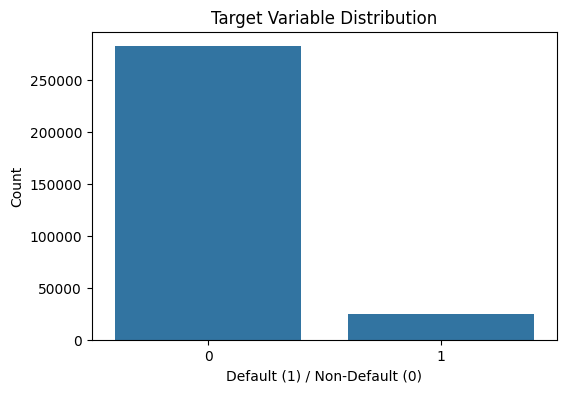

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=final_df)
plt.title("Target Variable Distribution")
plt.xlabel("Default (1) / Non-Default (0)")
plt.ylabel("Count")
plt.show()

print(final_df['TARGET'].value_counts(normalize=True))

# Distribution of Features

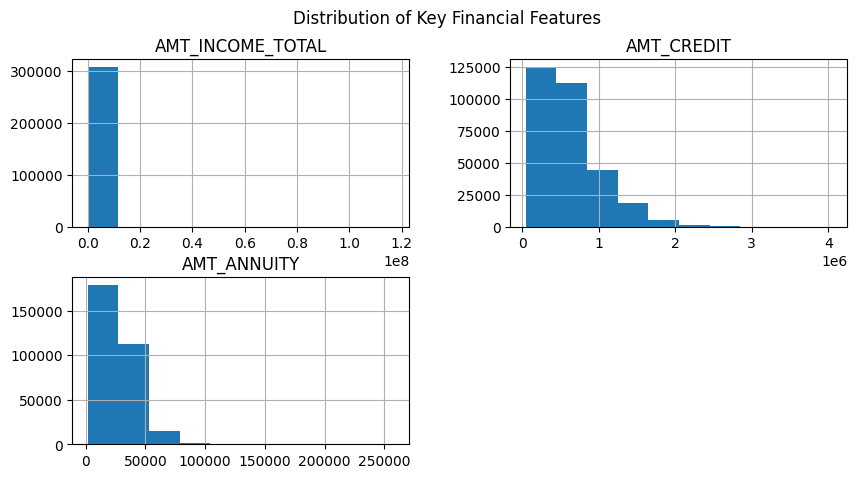

In [23]:
num_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

final_df[num_cols].hist(figsize=(10,5))
plt.suptitle("Distribution of Key Financial Features")
plt.show()

# Features vs Target

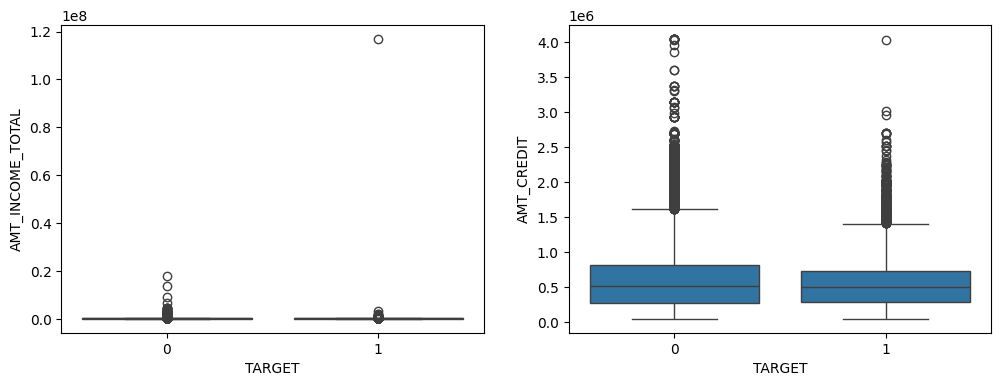

In [24]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=final_df)

plt.subplot(1,2,2)
sns.boxplot(x='TARGET', y='AMT_CREDIT', data=final_df)

plt.show()

# Categorical Feature Analysis

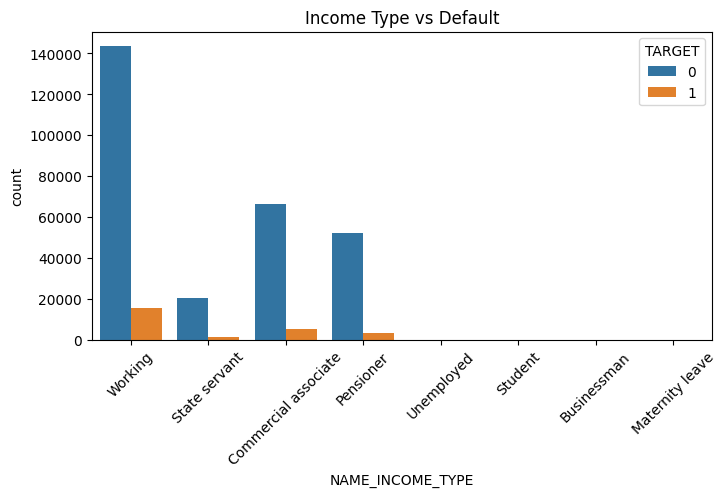

In [25]:
plt.figure(figsize=(8,4))
sns.countplot(x='NAME_INCOME_TYPE', hue='TARGET', data=final_df)
plt.xticks(rotation=45)
plt.title("Income Type vs Default")
plt.show()

# Corelation with Target

In [26]:
# Select only numeric columns
numeric_df = final_df.select_dtypes(include=['number'])

# Correlation with target
corr = numeric_df.corr()['TARGET'].sort_values(ascending=False)

print(corr.head(10))
print(corr.tail(10))

TARGET                         1.000000
DAYS_CREDIT_mean               0.082079
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
CC_AMT_BALANCE_mean            0.049729
FLAG_EMP_PHONE                 0.045982
Name: TARGET, dtype: float64
ELEVATORS_AVG                -0.035853
REGION_POPULATION_RELATIVE   -0.037227
FLOORSMAX_MODE               -0.038377
FLOORSMAX_MEDI               -0.039157
FLOORSMAX_AVG                -0.039385
AMT_GOODS_PRICE              -0.039623
DAYS_EMPLOYED                -0.044932
EXT_SOURCE_1                 -0.098887
EXT_SOURCE_3                 -0.155892
EXT_SOURCE_2                 -0.160295
Name: TARGET, dtype: float64


# Heatmap

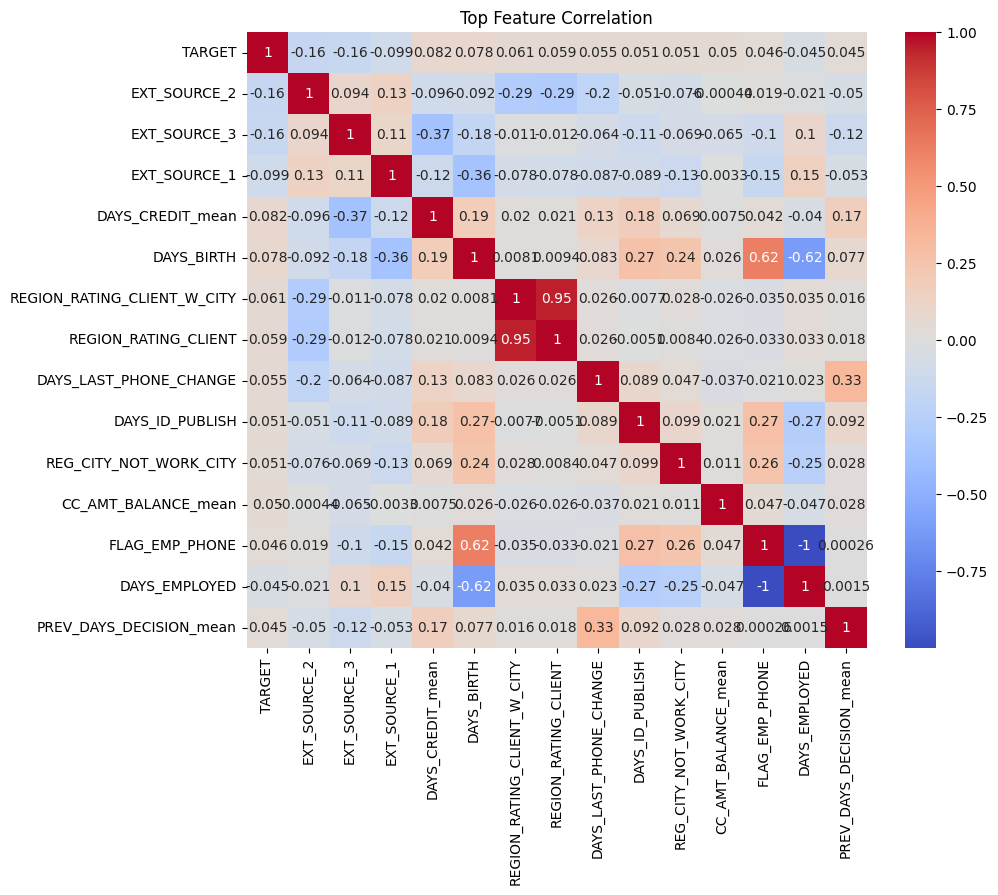

In [27]:
# Top correlated features
top_features = corr.abs().sort_values(ascending=False).index[:15]

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df[top_features].corr(), annot=True, cmap='coolwarm')
plt.title("Top Feature Correlation")
plt.show()

# Split features and target

In [28]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

# Replace inf values

In [29]:
X = X.replace([np.inf, -np.inf], np.nan)

# Separate Column types

In [30]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Handle missing Values

In [31]:
# Numeric
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Categorical
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

# Clip Extreme Value

In [32]:
X[num_cols] = X[num_cols].clip(-1e10, 1e10)

# ENCODING

In [33]:
X = pd.get_dummies(X, drop_first=True)

# Final Check

In [34]:
print("Missing:", X.isnull().sum().sum())
print("Any inf:", np.isinf(X).sum().sum())

Missing: 0
Any inf: 0


# SPLIT DATA

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# HANDLE IMBALANCE

In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# LOGISTIC REGRESSION

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, recall_score, precision_score, f1_score, confusion_matrix

log_model = LogisticRegression(max_iter=1000)

# Train
log_model.fit(X_train_res, y_train_res)

# Predict
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

# Metrics
print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

===== Logistic Regression =====
Accuracy: 0.6369607986602279
ROC-AUC: 0.6236512391010304
Recall: 0.5361530715005035
Precision: 0.11733591924890907
F1 Score: 0.19253580211196297

Confusion Matrix:
[[36513 20025]
 [ 2303  2662]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.65      0.77     56538
           1       0.12      0.54      0.19      4965

    accuracy                           0.64     61503
   macro avg       0.53      0.59      0.48     61503
weighted avg       0.87      0.64      0.72     61503



# DECISION TREE

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=10)

# Train
dt_model.fit(X_train_res, y_train_res)

# Predict
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

# Metrics
print("===== Decision Tree =====")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

===== Decision Tree =====
Accuracy: 0.8319106385054388
ROC-AUC: 0.6497763929379796
Recall: 0.23162134944612287
Precision: 0.1498761892349798
F1 Score: 0.1819908213324893

Confusion Matrix:
[[50015  6523]
 [ 3815  1150]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91     56538
           1       0.15      0.23      0.18      4965

    accuracy                           0.83     61503
   macro avg       0.54      0.56      0.54     61503
weighted avg       0.87      0.83      0.85     61503



# RANDOM FOREST

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)

# Train
rf_model.fit(X_train_res, y_train_res)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Metrics
print("===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

===== Random Forest =====
Accuracy: 0.9179552216965026
ROC-AUC: 0.68701624342202
Recall: 0.013293051359516616
Precision: 0.30985915492957744
F1 Score: 0.02549246813441483

Confusion Matrix:
[[56391   147]
 [ 4899    66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.31      0.01      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.61      0.51      0.49     61503
weighted avg       0.87      0.92      0.88     61503



# XGBOOST

In [40]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss')

# Train
xgb_model.fit(X_train_res, y_train_res)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

# Metrics
print("===== XGBoost =====")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

===== XGBoost =====
Accuracy: 0.9189633026031251
ROC-AUC: 0.7462966952829131
Recall: 0.03585095669687815
Precision: 0.4746666666666667
F1 Score: 0.06666666666666667

Confusion Matrix:
[[56341   197]
 [ 4787   178]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.47      0.04      0.07      4965

    accuracy                           0.92     61503
   macro avg       0.70      0.52      0.51     61503
weighted avg       0.89      0.92      0.89     61503



# MODEL COMPARISON

In [41]:
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{'='*10} {name} {'='*10}")

    acc = accuracy_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    rec = recall_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)

    print("Accuracy :", acc)
    print("ROC-AUC  :", roc)
    print("Recall   :", rec)
    print("Precision:", pre)
    print("F1 Score :", f1)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return acc, roc, rec, pre, f1

In [42]:
lr_metrics  = evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log)
dt_metrics  = evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt)
rf_metrics  = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
xgb_metrics = evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)


========== Logistic Regression ==========
Accuracy : 0.6369607986602279
ROC-AUC  : 0.6236512391010304
Recall   : 0.5361530715005035
Precision: 0.11733591924890907
F1 Score : 0.19253580211196297

Confusion Matrix:
[[36513 20025]
 [ 2303  2662]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.65      0.77     56538
           1       0.12      0.54      0.19      4965

    accuracy                           0.64     61503
   macro avg       0.53      0.59      0.48     61503
weighted avg       0.87      0.64      0.72     61503


========== Decision Tree ==========
Accuracy : 0.8319106385054388
ROC-AUC  : 0.6497763929379796
Recall   : 0.23162134944612287
Precision: 0.1498761892349798
F1 Score : 0.1819908213324893

Confusion Matrix:
[[50015  6523]
 [ 3815  1150]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91     56538
           1       0.15      0.23

In [43]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],

    "Accuracy": [
        lr_metrics[0],
        dt_metrics[0],
        rf_metrics[0],
        xgb_metrics[0]
    ],

    "ROC_AUC": [
        lr_metrics[1],
        dt_metrics[1],
        rf_metrics[1],
        xgb_metrics[1]
    ],

    "Recall": [
        lr_metrics[2],
        dt_metrics[2],
        rf_metrics[2],
        xgb_metrics[2]
    ],

    "Precision": [
        lr_metrics[3],
        dt_metrics[3],
        rf_metrics[3],
        xgb_metrics[3]
    ],

    "F1 Score": [
        lr_metrics[4],
        dt_metrics[4],
        rf_metrics[4],
        xgb_metrics[4]
    ]
})

# Sort by best metric (IMPORTANT)
comparison = comparison.sort_values(by="ROC_AUC", ascending=False)

comparison

,Model,Accuracy,ROC_AUC,Recall,Precision,F1 Score
3,XGBoost,0.918963,0.746297,0.035851,0.474667,0.066667
2,Random Forest,0.917955,0.687016,0.013293,0.309859,0.025492
1,Decision Tree,0.831911,0.649776,0.231621,0.149876,0.181991
0,Logistic Regression,0.636961,0.623651,0.536153,0.117336,0.192536


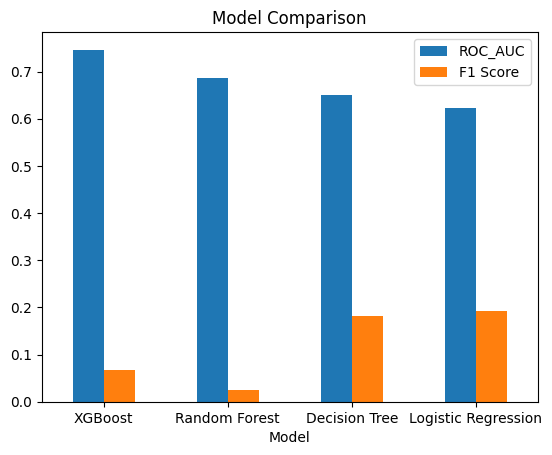

In [44]:
comparison.set_index("Model")[["ROC_AUC", "F1 Score"]].plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

# XGBoost Hyperparameter Tuning

In [45]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]
}
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=5,              # keep small for speed
    scoring='roc_auc',      # IMPORTANT for imbalance
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_res, y_train_res)
print("Best Parameters:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:,1]


Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters:
{'subsample': 1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.7}


In [46]:
xgb_tuned_metrics = evaluate_model(
    "Tuned XGBoost",
    y_test,
    y_pred_xgb_tuned,
    y_prob_xgb_tuned
)


========== Tuned XGBoost ==========
Accuracy : 0.91901208071151
ROC-AUC  : 0.7408264213354958
Recall   : 0.022960725075528703
Precision: 0.4672131147540984
F1 Score : 0.04377039738913419

Confusion Matrix:
[[56408   130]
 [ 4851   114]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.47      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.69      0.51      0.50     61503
weighted avg       0.88      0.92      0.88     61503



In [47]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Tuned XGBoost"],

    "Accuracy": [
        lr_metrics[0],
        dt_metrics[0],
        rf_metrics[0],
        xgb_tuned_metrics[0]
    ],

    "ROC_AUC": [
        lr_metrics[1],
        dt_metrics[1],
        rf_metrics[1],
        xgb_tuned_metrics[1]
    ],

    "Recall": [
        lr_metrics[2],
        dt_metrics[2],
        rf_metrics[2],
        xgb_tuned_metrics[2]
    ],

    "Precision": [
        lr_metrics[3],
        dt_metrics[3],
        rf_metrics[3],
        xgb_tuned_metrics[3]
    ],

    "F1 Score": [
        lr_metrics[4],
        dt_metrics[4],
        rf_metrics[4],
        xgb_tuned_metrics[4]
    ]
})

comparison = comparison.sort_values(by="ROC_AUC", ascending=False)
comparison

,Model,Accuracy,ROC_AUC,Recall,Precision,F1 Score
3,Tuned XGBoost,0.919012,0.740826,0.022961,0.467213,0.043770
2,Random Forest,0.917955,0.687016,0.013293,0.309859,0.025492
1,Decision Tree,0.831911,0.649776,0.231621,0.149876,0.181991
0,Logistic Regression,0.636961,0.623651,0.536153,0.117336,0.192536


# ANN Classification

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_model = Sequential()

# Input layer
ann_model.add(Dense(64, activation='relu', input_dim=X_train_res_scaled.shape[1]))

# Hidden layers
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dropout(0.3))

ann_model.add(Dense(16, activation='relu'))

# Output layer
ann_model.add(Dense(1, activation='sigmoid'))

In [58]:
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [59]:
history = ann_model.fit(
    X_train_res_scaled,
    y_train_res,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
y_prob_ann = ann_model.predict(X_test_scaled)
y_pred_ann = (y_prob_ann > 0.3).astype(int)

Epoch 1/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9370 - loss: 0.1940 - val_accuracy: 0.9934 - val_loss: 0.0120
Epoch 2/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.9422 - loss: 0.1790 - val_accuracy: 0.9933 - val_loss: 0.0128
Epoch 3/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9428 - loss: 0.1769 - val_accuracy: 0.9943 - val_loss: 0.0111
Epoch 4/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9430 - loss: 0.1756 - val_accuracy: 0.9942 - val_loss: 0.0110
Epoch 5/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.9431 - loss: 0.1745 - val_accuracy: 0.9948 - val_loss: 0.0108
Epoch 6/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.9434 - loss: 0.1736 - val_accuracy: 0.9952 - val_loss: 0.0094
Epoch 7/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.9434 - loss: 0.1728 - val_accuracy: 0.9944 - val_loss: 0.0119
Epoch 8/20
11308/11308 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 

In [60]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann))

# Evaluation
print("===== ANN Classification =====")
print("Accuracy:", accuracy_score(y_test, y_pred_ann))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_ann))
print("Recall:", recall_score(y_test, y_pred_ann))
print("Precision:", precision_score(y_test, y_pred_ann))
print("F1 Score:", f1_score(y_test, y_pred_ann))

[[55876   662]
 [ 4617   348]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     56538
           1       0.34      0.07      0.12      4965

    accuracy                           0.91     61503
   macro avg       0.63      0.53      0.54     61503
weighted avg       0.88      0.91      0.89     61503

===== ANN Classification =====
Accuracy: 0.9141667886119377
ROC-AUC: 0.7338962517950389
Recall: 0.07009063444108761
Precision: 0.3445544554455445
F1 Score: 0.11648535564853557


# Naive Bayes Classification

In [61]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

# Train
nb_model.fit(X_train, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:,1]

# Evaluation
print("===== Naive Bayes Classification =====")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

===== Naive Bayes Classification =====
Accuracy: 0.9128172609466205
ROC-AUC: 0.6016586835500704
Recall: 0.005840886203423968
Precision: 0.06373626373626373
F1 Score: 0.010701107011070111


# Comparison

In [62]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Naive Bayes",
        "ANN"
    ],

    "Accuracy": [
        lr_metrics[0],
        dt_metrics[0],
        rf_metrics[0],
        xgb_tuned_metrics[0],
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_ann)
    ],

    "ROC_AUC": [
        lr_metrics[1],
        dt_metrics[1],
        rf_metrics[1],
        xgb_tuned_metrics[1],
        roc_auc_score(y_test, y_prob_nb),
        roc_auc_score(y_test, y_prob_ann)
    ]
})

comparison.sort_values(by="ROC_AUC", ascending=False)

,Model,Accuracy,ROC_AUC
3,XGBoost,0.919012,0.740826
5,ANN,0.914167,0.733896
2,Random Forest,0.917955,0.687016
1,Decision Tree,0.831911,0.649776
0,Logistic Regression,0.636961,0.623651
4,Naive Bayes,0.912817,0.601659


# Challenges Faced

During the development of the loan default prediction model, several challenges were encountered. One of the primary issues was the imbalanced nature of the dataset, where the model tended to predict only the majority class. This was addressed by applying SMOTE to balance the class distribution. Another challenge involved handling a large number of missing values across multiple features, which was managed using median and mode imputation techniques, along with the removal of irrelevant columns.

Additionally, the Artificial Neural Network (ANN) model initially produced an F1 score of zero, indicating that it failed to correctly classify the minority class. This issue arose due to the lack of class balancing and an inappropriate classification threshold. It was mitigated by applying class weights and tuning the decision threshold to improve sensitivity toward the minority class.

The Naive Bayes model also exhibited poor performance, primarily because it assumes feature independence, which does not hold true for this dataset. Lastly, the large size of the dataset posed computational challenges, which were addressed by using efficient algorithms such as XGBoost and applying data sampling techniques where necessary.

# Key Business Insights

The analysis revealed several important business insights that can support better decision-making in loan approval processes. Customers with a high debt-to-income ratio were found to have a significantly higher risk of default. Additionally, an applicant’s previous credit behavior emerged as a strong predictor of future repayment patterns. These findings suggest that financial institutions should incorporate a robust risk scoring system into their loan approval framework to effectively identify and manage high-risk customers.



# Conclusion

This project successfully developed a machine learning model to predict loan defaults using historical financial and demographic data. Multiple models were trained and evaluated, and the issue of class imbalance was effectively addressed to improve model performance. Among all the models tested, XGBoost emerged as the most reliable and accurate model for predicting loan default risk.

The final outcome of this project enhances the ability to identify high-risk customers, thereby helping financial institutions reduce potential financial losses. Furthermore, the implementation of such predictive models supports data-driven decision-making, leading to more efficient and reliable loan approval processes.